# 開始建立影像辨識環境
## Colab

步驟1：連結到自己的雲端硬碟，後續可以直接啟用辨識

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


步驟2：將路徑移動到自己的雲端硬碟

In [9]:
%cd drive/MyDrive/Colab\ Notebooks
%ls

[Errno 2] No such file or directory: 'drive/MyDrive/Colab Notebooks'
/content/drive/MyDrive/Colab Notebooks
1208_建立Colab影像辨識環境.ipynb  test.ipynb


步驟3：選擇GPU
(1)編輯(2)筆記本設定

步驟3-1：查看系統顯示卡規格(NVIDIA AI加速)

In [10]:
!nvidia-smi

Sat Aug 16 06:34:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Darknet神經網路建立


我們使用的Darknet為Alex版本的Darknet網路框架

步驟4：將計畫檔複製到我們的雲端硬碟

In [11]:
# clone darknet repo
!git clone https://github.com/AlexeyAB/darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15903, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 15903 (delta 0), reused 1 (delta 0), pack-reused 15900 (from 1)
Receiving objects: 100% (15903/15903), 14.46 MiB | 11.49 MiB/s, done.
Resolving deltas: 100% (10703/10703), done.
Updating files: 100% (2054/2054), done.


步驟5：修改編譯設定，主要是因為Colab雲端電腦有提供高效能GPU，所以我們使用Nvidia 所提供的Cuda平行運算架構來建立Darknet。

In [12]:
# change makefile to have GPU, OPENCV and LIBSO enabled

!sed -i 's/OPENCV=0/OPENCV=1/' darknet/Makefile
!sed -i 's/GPU=0/GPU=1/' darknet/Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' darknet/Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' darknet/Makefile
!sed -i 's/LIBSO=0/LIBSO=1/' darknet/Makefile

步驟6：編譯Darknet（需要1-3分鐘左右）

In [13]:
# make darknet (builds darknet so that you can then use the darknet.py file and have its dependencies)
%cd darknet
!make

/content/drive/MyDrive/Colab Notebooks/darknet
mkdir -p ./obj/
mkdir -p backup
mkdir -p results
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -fPIC -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: variable ‘rgb’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  945 |                 float rgb[3];
      |                       ^~~
./src/image_opencv.cpp: In function ‘void cv_draw_object(image, float*, int, int, int*, float*, in

步驟7：下載YOLOv4 Pre-Trained類神經網路模型的權重檔，本模型能辨識日常生活中的80個物件，相關資料都在cfg/coco.names中

YOLOv4：全模型，有162層CNN所建立的類神經網路，正確率較高，但效能較低

YOLOv4-tiny：精簡模型，只有38層，效率高，但辨識率普通

In [14]:
#YOLOv4
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights
#YOLOv7
!wget https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov7.weights
!wget https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov7-tiny.weights

--2025-08-16 06:38:45--  https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/75388965/228a9c00-3ea4-11eb-8e80-28d71569f56c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-08-16T07%3A13%3A26Z&rscd=attachment%3B+filename%3Dyolov4-tiny.weights&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-08-16T06%3A13%3A24Z&ske=2025-08-16T07%3A13%3A26Z&sks=b&skv=2018-11-09&sig=F7S3RDS7SRqqHlmKhhSVa%2F5kIoxZmMvMTIwLBEP%2F464%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1NTMyNjYyNiwibmJmIjoxNzU1MzI2MzI2LCJwYXRoIjoicmVsZWFzZWFzc

# 載入Darknet

步驟8：載入影像擷取即顯示用的相關套件

(實際內容不重要)

In [15]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import urllib.request
import time
import matplotlib.pyplot as plt
%matplotlib inline

步驟9：選擇使用的YOLO版本，需有三個設定

1:cfg網路設定檔

2:weights類神經網路權重檔

3:data能辨識的物件名稱

In [16]:
#選擇你要用的網路型態
YOLO_cfg='cfg/yolov4.cfg' # cfg/yolov4-tiny.cfg
YOLO_weight='yolov4.weights' # yolov4.weights
YOLO_label='cfg/coco.data'

步驟10：載入神經網路

建立darknet_dect副程式

In [17]:

from darknet import *
network, class_names, class_colors = load_network(YOLO_cfg, YOLO_label, YOLO_weight)
width = network_width(network)
height = network_height(network)

# darknet helper function to run detection on image
def darknet_dect(img, width, height):
  darknet_image = make_image(width, height, 3)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img_resized = cv2.resize(img_rgb, (width, height),interpolation=cv2.INTER_LINEAR)

  # get image ratios to convert bounding boxes to proper size
  img_height, img_width, _ = img.shape
  width_ratio = img_width/width
  height_ratio = img_height/height

  # run model on darknet style image to get detections
  copy_image_from_bytes(darknet_image, img_resized.tobytes())
  detections = detect_image(network, class_names, darknet_image)
  free_image(darknet_image)
  return detections, width_ratio, height_ratio

# 測試

步驟11：先使用內建的照片進行測試，內建的照片都放在data中，可以用雲端硬碟來事先查看

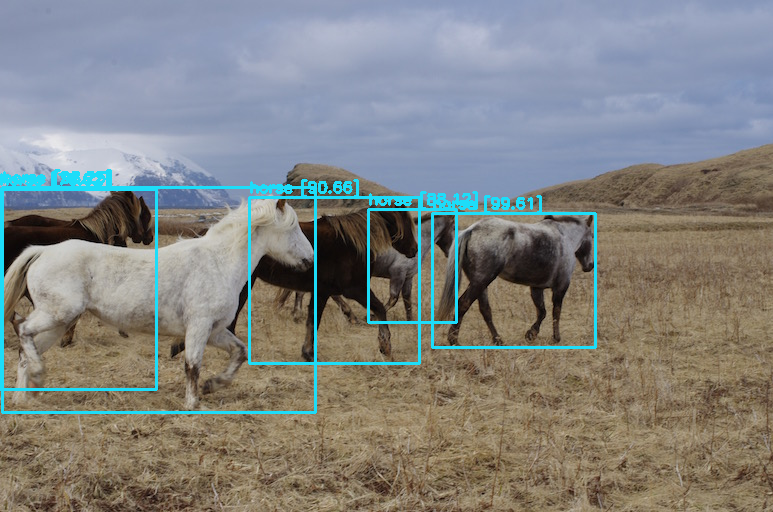

In [18]:
image = cv2.imread("data/horses.jpg")
detections, width_ratio, height_ratio = darknet_dect(image, width, height)
# 物件名稱 信任程度  位置
for label, confidence, bbox in detections:
  left, top, right, bottom = bbox2points(bbox) #比例
  left, top, right, bottom = int(left * width_ratio), int(top * height_ratio), int(right * width_ratio), int(bottom * height_ratio) #像素座標
  cv2.rectangle(image, (left, top), (right, bottom), class_colors[label], 2) #繪出方形(bbox)
  #      照片    文字內容                     位置         字形          大小   顏色      寬度
  cv2.putText(image, "{} [{:.2f}]".format(label, float(confidence)),(left, top - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5,class_colors[label], 2)

cv2_imshow(image)

步驟12：讀取網路的照片

從網路上，搜尋一張照片，例如「路口」，https://www.upmedia.mg/upload/article/20200904161256111093.JPG

複製他的網址後，先查看原始圖片，然後拿來偵測裡面出現的物件

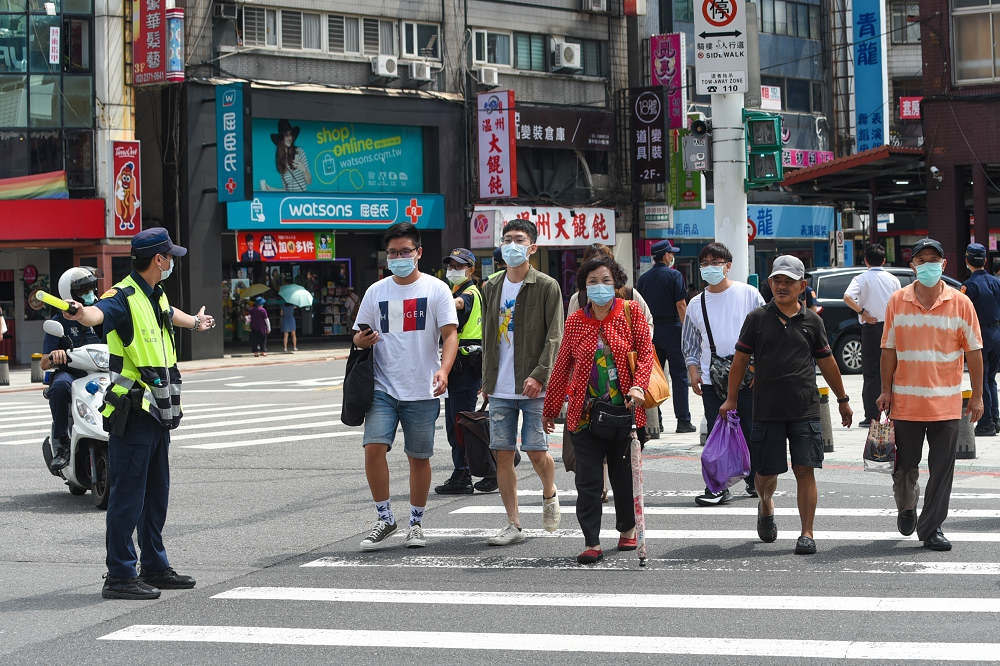

In [19]:
url = "https://www.upmedia.mg/upload/article/20200904161256111093.JPG"
filename ='test.jpg'
urllib.request.urlretrieve(url, filename)
img_test = cv2.imread(filename)

cv2_imshow(img_test) #顯示圖片

步驟13：使用Darknet進行網路照片物件偵測

{'handbag': 4, 'person': 13, 'motorbike': 1, 'umbrella': 1}


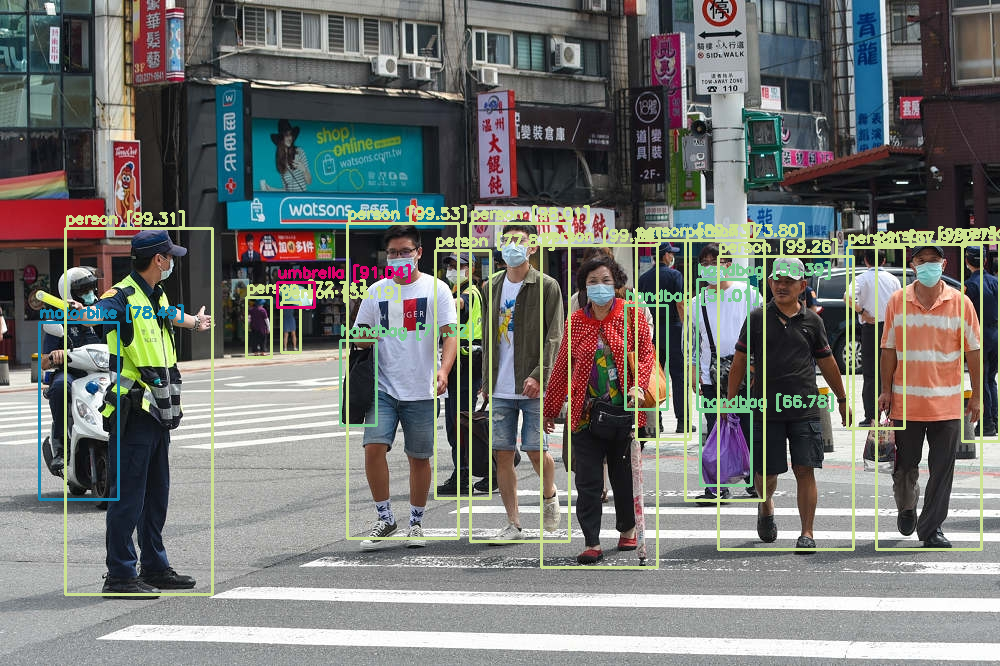

In [20]:
objCount={}
detections, width_ratio, height_ratio = darknet_dect(img_test, width, height)
for label, confidence, bbox in detections:
  left, top, right, bottom = bbox2points(bbox) #比例
  left, top, right, bottom = int(left * width_ratio), int(top * height_ratio), int(right * width_ratio), int(bottom * height_ratio) #像素座標
  cv2.rectangle(img_test, (left, top), (right, bottom), class_colors[label], 2) #繪出方形(bbox)
  #      照片    文字內容                     位置         字形          大小   顏色      寬度
  cv2.putText(img_test, "{} [{:.2f}]".format(label, float(confidence)),(left, top - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5,class_colors[label], 2)
  #利用python字典將所有的detections的label列舉出現次數
  if label in objCount.keys():
    objCount[label] = objCount[label] + 1
  else:
    objCount[label] = 1
print(objCount)
cv2_imshow(img_test)